# LABF_2026 — Clothes Inpainting and LoRA Garment Personalisation

Master's degree in Intelligent Systems &middot; Subject: 11754 — Deep Learning
&middot; Year: 2026-2027

In this final project you will work on **two complementary tasks** that
showcase modern generative pipelines:

- **Task A — Design inpainting on a garment.** Use CLIPSeg to localise
  a garment in a photo, then use Stable Diffusion 2 Inpainting to
  paint a creative design (a pattern, an illustration, or typography)
  onto the masked region while preserving the garment's silhouette.
- **Task B — Garment personalisation.** Train a small LoRA adapter on
  5–10 photos of one specific garment you own, then generate new
  photos of that exact garment in different scenes via text-to-image.

Task C ties the two together with a CLIP-as-critic comparison.

The notebook is structured in three memory phases (each phase frees the
previous models before loading the next) so the whole thing runs on a
single Google Colab T4 session, but you can split it into 2 or 3
notebooks if you prefer.

## Submission requirements

Submit exactly three things, and nothing else:

1. **Two photos of the garment on a flat surface**, one front and one
   back. Save them as `garment_front.jpg` and `garment_back.jpg` in
   `photos/lora_garment/` so the notebook picks them up.
2. **The executed notebook** (`LAB_F_stv.ipynb`) with all cell outputs
   preserved.
3. **The helper file** you used (`helper_LF_stv.py`).

If you photograph another person at any point during the lab you need
their authorisation; in any case, no photos of people are part of the
submission &mdash; the LoRA training set is photos of the *garment* on
a flat surface, taken from different angles / under different lighting
/ with different fold patterns.

## Explanations are mandatory

Every result in this notebook must be accompanied by an explanation.
You can place the explanation either:

- **As inline code comments**, when the explanation is about *what
  the code does* and *why* (e.g. why a particular function is
  appropriate, why a hyperparameter was set to a given value).
- **As a markdown text cell**, when the explanation is about a
  qualitative observation, a comparison between outputs, or a
  reflection.

Results without explanations will be considered incomplete. This is
the same convention used throughout the rest of the labs in the
course.

## 0. Setup

In [1]:
# 0.1 Environment detection
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"IN_COLAB = {IN_COLAB}")

IN_COLAB = True


In [10]:
# 0.2 Drive mount + project directory
import os
import sys
from pathlib import Path

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/gdrive")
    PROJECT_DIR = Path("/content/gdrive/MyDrive/EDISS/UIB/DL/LABF_2026")
    os.chdir(PROJECT_DIR)
else:
    PROJECT_DIR = Path.cwd()

sys.path.append(str(PROJECT_DIR))
print(f"PROJECT_DIR = {PROJECT_DIR}")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
PROJECT_DIR = /content/gdrive/MyDrive/EDISS/UIB/DL/LABF_2026


In [4]:
# 0.3 Install dependencies (Colab only; the `dl-course` conda env has them).
# The `!pip install` lines below run as shell commands once jupytext
# converts this `.py` source into the `.ipynb` notebook; in the raw `.py`
# they are bare comments, so we add a `pass` to keep the source
# importable.
if IN_COLAB:
    # fmt: off
    # ruff: noqa: E501
    !pip install -q diffusers==0.37.1 transformers==5.5.4 accelerate==1.13.0 peft==0.19.1 xformers==0.0.35 safetensors==0.7.0 scipy==1.17.1 ftfy==6.3.1 jupytext==1.19.1
    !pip install -q git+https://github.com/openai/CLIP.git
    # Colab preinstalls torchao 0.10.0; peft's strict version check rejects it.
    # We don't use torchao quantization, so removing it is the cleanest fix.
    !pip uninstall -q -y torchao
    pass

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 kB 19.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
# 0.4 Imports
import gc                                # used by Phase cleanup cells
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

import clip
from diffusers import (
    StableDiffusionInpaintPipeline,
    StableDiffusionPipeline,
    EulerDiscreteScheduler,
    DPMSolverMultistepScheduler,
)
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from peft import LoraConfig

from helper_LF_stv import (
    DEFAULT_NEGATIVE,
    clip_score,
    show_image_grid,
    show_mask_overlay,
    setup_lora_training,
    sample_batch,
    save_lora_adapter,
    delete_trained_adapter,
    generate_with_lora,
)

# Use a torch.device throughout (not a bare string) so later helpers
# like torch.Generator(device) and torch.autocast(device_type=...) get
# unambiguous device handling on both CUDA and CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    raise RuntimeError(
        "LABF_2026 requires CUDA (LoRA training is GPU-only). "
        "Run on a Colab T4 or local NVIDIA GPU with the conda env "
        "`dl-course` activated."
    )

_BICUBIC = getattr(Image, "Resampling", Image).BICUBIC

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


## 1. Theory recap

The lecture deck (`texts/Garment_Personalization_Architecture_stv.pptx`)
and its speaker notes (`texts/Notes pages_stv.txt`) cover every concept
used in this notebook. Open the speaker notes alongside the slides as
you work through the cells &mdash; the lab assumes the conceptual
material is already familiar.

## 2. Input photos

Place your photos in `LABF_2026/photos/lora_garment/`:

- **5&ndash;10 photos of a single garment laid on a flat surface**,
  taken from different angles, with different fold patterns and / or
  different surfaces / lighting. The full set is used by Task B for
  LoRA training, so variety matters &mdash; a model trained on five
  near-identical shots will overfit to that exact pose.
- The **first photo (sorted alphabetically)** is also used as the
  canvas for Task A's design inpainting. Name it `garment_front.jpg`
  so it sorts first &mdash; it should be a clean, garment-fills-the-frame,
  flat-laid front view.
- Pick a garment with a distinctive feature (a logo, a bold print, an
  unusual colour). A plain solid-colour item is hard for the LoRA to
  lock onto.

Submission only includes `garment_front.jpg` and `garment_back.jpg`
&mdash; the other working photos stay on your machine.

All photos are centre-cropped and resized to 512&times;512 inside the
pipeline.

In [11]:
PHOTOS_LORA = PROJECT_DIR / "photos" / "lora_garment"
LORA_OUTPUT = PROJECT_DIR / "lora_adapter"
LORA_WEIGHTS_FILE = LORA_OUTPUT / "pytorch_lora_weights.safetensors"


def load_and_prepare(path: Path, size: int = 512) -> Image.Image:
    """Load image from disk, resize (keep aspect, centre-crop) to size."""
    img = Image.open(path).convert("RGB")
    scale = size / min(img.size)
    new_size = (int(img.width * scale), int(img.height * scale))
    img = img.resize(new_size, _BICUBIC)
    left = (img.width - size) // 2
    top = (img.height - size) // 2
    return img.crop((left, top, left + size, top + size))


def _list_photos(folder: Path) -> list[Path]:
    """Return a sorted, de-duplicated list of image files in ``folder``."""
    patterns = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
    files: set[Path] = set()
    for pat in patterns:
        files.update(folder.glob(pat))
    return sorted(files)


lora_photos = _list_photos(PHOTOS_LORA)
print(f"Task B photos (lora_garment): {len(lora_photos)}  (need 5–10)")
if len(lora_photos) < 5:
    raise RuntimeError(
        f"Task B needs at least 5 photos in {PHOTOS_LORA}/, "
        f"found {len(lora_photos)}."
    )

# Task A uses the first lora_garment/ photo (alphabetical) — make this
# `garment_front.jpg` so it's the front, flat-laid view.
TASK_A_PHOTO = lora_photos[0]
print(f"Task A will use: {TASK_A_PHOTO.name}")

Task B photos (lora_garment): 5  (need 5–10)
Task A will use: garment_front.png


## 3. Task A &mdash; Design inpainting on a garment

We chain CLIPSeg (text-driven segmentation) and Stable
Diffusion 2 Inpainting to **paint a creative design onto an existing
garment**. CLIPSeg locates the garment from a short text description;
SD-2 Inpainting then composites a new pattern, illustration, or
typography onto the masked region while keeping the garment's
silhouette and base colour intact. The LoRA adapter is *not*
involved in this task &mdash; only base pretrained models.

In [12]:
# Instructor code: load CLIPSeg.
clipseg_processor = CLIPSegProcessor.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)
clipseg_model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
).to(device).eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.73k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/974 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/603M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
# Instructor code: load SD-2 Inpainting. The community mirror
# `sd2-community/...` hosts the diffusers-format checkpoint. The choice
# of scheduler and inference budget is part of the lab — see Task A2.
sd_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-inpainting",
    torch_dtype=torch.float16,
    variant="fp16",
).to(device)
sd_inpaint.enable_xformers_memory_efficient_attention()  # CUDA-only path
sd_inpaint.vae.enable_slicing()

model_index.json:   0%|          | 0.00/544 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd2-community--stable-diffusion-2-inpainting/snapshots/5f74973cbb64c8568780732c17f43eb269d63a0d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Task A1 &mdash; `clipseg_heatmap`

Implement `clipseg_heatmap(image: PIL.Image.Image, prompt: str) -> np.ndarray`
that runs CLIPSeg on the (image, prompt) pair and returns a 2-D numpy
array of shape `(512, 512)` with values in `[0, 1]`. The output is a
soft mask suitable for downstream inpainting.

Resources:
- The `clipseg_processor` and `clipseg_model` objects are loaded in the
  cell above.
- The
  [CLIPSeg model card on HuggingFace](https://huggingface.co/CIDAS/clipseg-rd64-refined)
  documents the call signature.
- The native logit map from CLIPSeg is at a different resolution from
  the photo; you will need to map logits into [0, 1] and resize the
  result so its spatial dimensions match the photo.
- The slides explain why the mask is best left *soft* rather than
  thresholded.

Add an inline comment or a markdown cell explaining the function you
chose to map logits into [0, 1] and why it is appropriate (mandatory
&mdash; see "Explanations are mandatory" at the top of the notebook).

In [14]:
def clipseg_heatmap(image: Image.Image, prompt: str) -> np.ndarray:
    """Run CLIPSeg and return a soft mask in [0, 1], resized to 512x512."""
    # - processor: CLIP normalisation + resize to native 352x352 + tokenise
    # - model is frozen -> no_grad to skip autograd
    inputs = clipseg_processor(
        text=[prompt], images=[image],
        return_tensors="pt", padding=True,
    ).to(device)
    with torch.no_grad():
        logits = clipseg_model(**inputs).logits      # (1, 352, 352), raw logits

    # logits -> [0, 1]:
    # - sigmoid, not softmax: prediction is independent per pixel (no
    #   class competition), so softmax's cross-pixel normalisation is wrong
    # - keep mask SOFT (no threshold) for smooth blending in inpainting
    probs = torch.sigmoid(logits)

    # resize 352 -> 512 to match the photo:
    # - F.interpolate bilinear needs 4D input -> add channel dim
    # - bilinear is smooth + cheap; align_corners=False is the modern default
    probs = probs.unsqueeze(1)                       # (1, 1, 352, 352)
    heatmap = F.interpolate(
        probs, size=(512, 512),
        mode="bilinear", align_corners=False,
    ).squeeze().cpu().numpy()                        # (512, 512)
    return heatmap

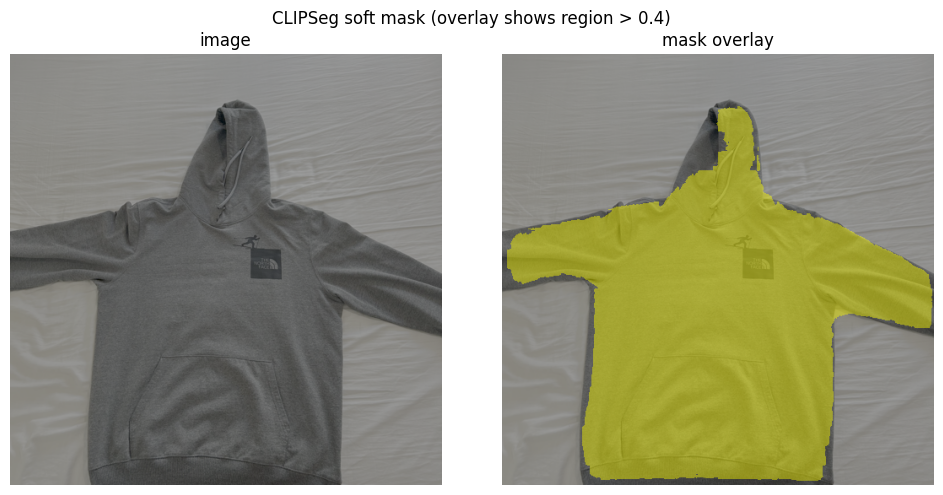

In [25]:
# Demo: visualise the soft mask on the chosen Task A photo. We pass
# the soft heatmap directly to ``show_mask_overlay``; the boolean
# threshold > 0.4 below is **only** for the visualisation, not for
# inpainting — the inpaint step will use the soft heatmap unchanged.
_demo_image = load_and_prepare(TASK_A_PHOTO)
_demo_heatmap = clipseg_heatmap(_demo_image, "the flat hoodie laid on a surface")
show_mask_overlay(_demo_image, _demo_heatmap > 0.4,
                  title="CLIPSeg soft mask (overlay shows region > 0.4)")

### Task A2 &mdash; Paint three creative designs onto the garment

Use `TASK_A_PHOTO` as your working image. Write a `segment_prompt`
describing what to mask (typically the garment, e.g. `"the t-shirt"`)
and run inpainting on **at least these three required prompts**:

- `"a zebra t-shirt"`
- `"an astronaut riding a horse"`
- `"a omniscient eye"`

These three are required so submissions can be compared on the same
prompts. You may add more of your own choosing.

The prompt steers what gets painted; the soft mask (from your
`clipseg_heatmap`) keeps the underlying garment silhouette and base
colour intact.

You also choose:

- The **scheduler** for the SD-2 Inpainting pipeline (e.g. one of the
  schedulers imported at the top of the notebook).
- The **number of denoising steps** and the **classifier-free
  guidance scale**. Both are well-known levers; pick values that
  produce sharp, on-prompt outputs and explain your choices in a
  markdown cell beneath the code.

Use the seed `42` and `DEFAULT_NEGATIVE` (already imported) for the
negative prompt &mdash; this keeps the comparison reproducible across
re-runs.

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

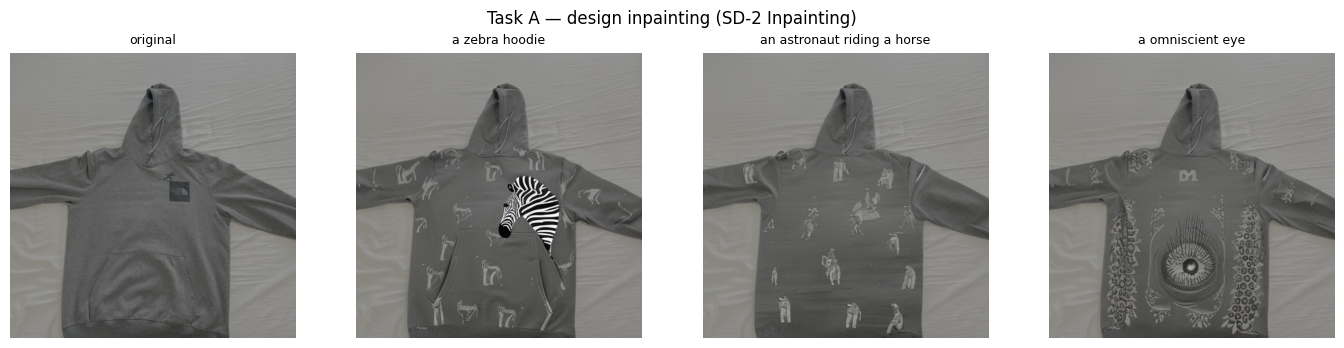

In [28]:
work_image = load_and_prepare(TASK_A_PHOTO)
segment_prompt = "the hoodie"                               # TODO if needed
positive_prompts = [
    # Modified to match the grament                                      # TODO: at minimum these three
    "a zebra hoodie",
    "an astronaut riding a horse",
    "a omniscient eye",
]

# Scheduler choice:
# - DPM-Solver-Multistep: fast deterministic, converges in ~25-30 steps
# - swapped in only for inference; SD-2's default is for training
sd_inpaint.scheduler = DPMSolverMultistepScheduler.from_config(
    sd_inpaint.scheduler.config
)
# Inference budget:
# - 30 steps: plateau for DPM-Solver-Multistep; <20 -> soft, >40 -> wasted
# - guidance 7.5: SD-2 canonical default
#     <5 drifts off-prompt, >12 over-saturates colours
NUM_STEPS = 30
GUIDANCE = 7.5

heatmap = clipseg_heatmap(work_image, segment_prompt)
mask_pil = Image.fromarray(
    np.clip(np.round(heatmap * 255), 0, 255).astype(np.uint8)
).convert("L")

swap_outputs = []
for prompt in positive_prompts:
    # - fresh generator per call so all three prompts see the same
    #   seed-42 noise -> fair side-by-side comparison
    generator = torch.Generator(device).manual_seed(42)
    with torch.autocast(device_type=device.type, dtype=torch.float16):
        out = sd_inpaint(
            prompt=prompt,
            negative_prompt=DEFAULT_NEGATIVE,
            image=work_image,
            mask_image=mask_pil,
            num_inference_steps=NUM_STEPS,
            guidance_scale=GUIDANCE,
            generator=generator,
        ).images[0]
    swap_outputs.append(out)

show_image_grid(
    [work_image] + swap_outputs,
    ["original"] + positive_prompts,
    rows=1, cols=1 + len(positive_prompts),
    title="Task A — design inpainting (SD-2 Inpainting)",
)

### VRAM cleanup before Task B

We are done with CLIPSeg and SD-2 Inpainting. Free their VRAM before
loading the text-to-image base for Task B &mdash; on a Colab T4 (16 GB)
keeping both pipelines resident leaves no room for LoRA training
activations.

In [29]:
del clipseg_model, clipseg_processor, sd_inpaint
gc.collect()
torch.cuda.empty_cache()
print("Task A VRAM freed.")
print(f"VRAM allocated to live tensors: "
      f"{torch.cuda.memory_allocated()/1e9:.2f} GB")
# Note: PyTorch's caching allocator keeps freed memory in a process-local
# pool, so `nvidia-smi` will still show several GB used by this Python
# process even after the print above reports a low number. The pool is
# reused by the next pipeline load, which is why the three-phase
# structure works on a 16 GB T4.

Task A VRAM freed.
VRAM allocated to live tensors: 0.01 GB


## 4. Task B &mdash; Personalised generation via LoRA on SD-2-1-base

We train a small LoRA adapter on 5&ndash;10 photos of
*your* specific garment so that prompts containing your trigger token
produce that exact garment. We then use text-to-image generation to
place the garment in different scenes.

Critically, we train the LoRA on the **non-inpainting** SD-2-1-base
(4-channel UNet). The reason is part of the lab &mdash; the helper's
`setup_lora_training` will raise a clear `ValueError` if you pass an
inpainting pipeline, and the slides explain *why* training a LoRA on
the 9-channel inpainting U-Net does not work.

The fixed pieces of the training recipe are:

- FP16 base, FP32 LoRA, gradient checkpointing &mdash; handled by the
  helper.
- Per-step `batch_size = 1` (VRAM-bound on a T4).
- A horizontal-flip augmentation (cheap, helpful for a small set).

Everything else is yours to choose: the rank, `lora_alpha`,
`target_modules`, the number of steps, the learning rate, and the
caption template. The next few cells walk you through these decisions.

In [ ]:
# Instructor code: load SD-2-1-base (text-to-image) for LoRA training
# and inference. The helper checks `pipe.unet.in_channels == 4` so this
# pipe is the right one. The default scheduler is fine for *training*;
# at inference time you may want a faster sampler — see Task B2.
sd_base = StableDiffusionPipeline.from_pretrained(
    "sd2-community/stable-diffusion-2-1-base",
    torch_dtype=torch.float16,
    variant="fp16",
).to(device)
sd_base.enable_xformers_memory_efficient_attention()
sd_base.vae.enable_slicing()

### Task B1 &mdash; Prepare the LoRA training set

Assemble a list of `(PIL.Image, prompt)` pairs from `lora_photos`.
Every image uses the **same caption**, of the form

    "a photo of <colour> <trigger> <class>"

where you choose the three slots:

- **`<colour>`** &mdash; the dominant colour of your garment (e.g.
  `"orange"`, `"navy"`, `"black"`). The slides explain why a UNet-only
  LoRA needs the colour word at training time even when you "obviously"
  know the garment's colour.
- **`<trigger>`** &mdash; a *rare* token. The slides explain why
  rarity is what makes a good trigger; pick one and justify in a
  markdown cell.
- **`<class>`** &mdash; the class noun, e.g. `"t-shirt"`,
  `"hoodie"`, `"jacket"`.

The same caption template is used at inference, with a scene appended
at the end (Task B2). Store the list in a variable called
`lora_dataset`.

In [ ]:
# TODO: Task B1 — fill in <colour>, <trigger>, <class> for your garment,
# then build a list of (PIL.Image, prompt) pairs from lora_photos with
# this caption for every photo.
lora_caption = "a photo of <colour> <trigger> <class>"
lora_dataset = [...]

### Hyperparameter choices for LoRA training

Pick values within the ranges below. The convention `lora_alpha = 2 * r`
is widespread in DreamBooth-LoRA recipes and keeps the internal scale
(`lora_alpha / r`) fixed at 2 regardless of rank &mdash; meaning rank
can be tuned without also changing the effective magnitude of the
adapter at training time.

**Yours to choose**:

- `r` (rank) &isin; `{4, 8, 16}` &mdash; adapter capacity.
- `lora_alpha = 2 * r` (convention) &mdash; training-time scale.
- `target_modules` &mdash; the four attention projection names in
  Stable Diffusion's U-Net. Look at the `peft.LoraConfig` documentation
  and at the diffusers `train_dreambooth_lora.py` example to find the
  right names.
- `n_steps` &isin; `[500, 2000]` &mdash; tied to your subject-set size.
- `lr` &isin; `[5e-5, 5e-4]` &mdash; AdamW learning rate.

**Pre-fixed (do not change)**:

- `batch_size = 1` &mdash; VRAM-bound on T4.
- `lora_dropout = 0.0` and `bias = "none"` &mdash; standard for
  DreamBooth-LoRA on small subject sets.
- `seed = 1234` &mdash; reseeded inside the training cell so the random
  timestep, the noise, and the photo-sampling order are deterministic
  across re-runs.

Briefly justify your `r`, `lora_alpha`, `target_modules`, `n_steps`,
and `lr` choices in a markdown cell beneath the code (mandatory).

In [ ]:
# TODO: instantiate a peft.LoraConfig with your chosen rank, alpha, and
# target_modules. lora_dropout=0.0, bias="none".
lora_config = ...                                     # TODO

### Train the LoRA adapter &mdash; per-step body

You write the per-step body of the diffusion training loop. The
skeleton below provides the loop, the (image, prompt) sampler, and
the optimiser bookkeeping; you fill in the seven operations marked
TODO. You saw exactly the same forward training pass in LAB04, applied
in pixel space &mdash; here it operates on the VAE's 4&times;64&times;64
latent space.

The whole cell is skipped if a previous run produced an adapter file
&mdash; this matters: ``setup_lora_training`` injects a fresh
"default" LoRA into the U-Net, and a *second* call against the same
pipe (e.g. on a re-run after the adapter exists) would conflict with
the trained adapter loaded by the next cell.

On a Colab T4, expect ~25 minutes for typical settings.

In [ ]:
if not LORA_WEIGHTS_FILE.exists():
    # Build the training state (LoRA injection, optimiser, frozen base).
    state = setup_lora_training(sd_base, lora_config, lr=...)  # TODO: lr

    # Reproducibility: seed the numpy RNG (used for batch sampling),
    # the global torch RNG (used by torch.randn_like and torch.randint),
    # and the CUDA RNG (used for any device-side randomness).
    SEED = 1234
    rng = np.random.default_rng(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    n_steps = ...                  # TODO: pick a value in [500, 2000]

    for step in range(n_steps):
        # Sample one batch (the helper handles random selection,
        # optional horizontal flip, centre-crop, dtype, device).
        image_tensor, prompt = sample_batch(lora_dataset, state, rng,
                                            augment=True)

        # Clear stale gradients before this step's forward pass (best
        # practice; ``set_to_none=True`` saves a small amount of memory
        # versus the default zero-fill).
        state.optimizer.zero_grad(set_to_none=True)

        # ---- 1. VAE-encode the image to a latent. Use state.vae.encode;
        #         draw a sample from the posterior (.latent_dist.sample())
        #         and scale by state.vae.config.scaling_factor. The VAE
        #         is frozen, so wrap in torch.no_grad(). After encoding,
        #         cast to FP32 for numerical stability in the noise math
        #         that follows.
        latent = ...                                              # TODO

        # ---- 2. Text-encode the prompt. The state helper does the
        #         tokenise -> frozen-encode -> cast -> grad-attach chain
        #         in one call.
        encoder_hidden_states = state.encode_text(prompt)

        # ---- 3. Sample Gaussian noise of the latent's shape.
        noise = ...                                               # TODO

        # ---- 4. Sample a random timestep t per batch element, uniform
        #         in [0, state.noise_scheduler.config.num_train_timesteps).
        t = ...                                                   # TODO

        # ---- 5. Add noise to the latent at the schedule's level for t.
        #         Use state.noise_scheduler.add_noise.
        noisy_latent = ...                                        # TODO

        # ---- 6. Predict the noise with the LoRA-augmented U-Net.
        #         The U-Net call signature is
        #             state.unet(noisy, t, encoder_hidden_states=...).sample
        #         Two implementation notes already wired up below:
        #         - We cast the noisy latent to state.base_dtype (the
        #           frozen-base dtype, FP16) and wrap in state.attach_grad
        #           for gradient-checkpoint compatibility (without this
        #           the LoRA params receive no gradient).
        #         - We wrap the U-Net forward in torch.autocast so FP16
        #           base ops compose correctly with FP32 LoRA params.
        unet_input = state.attach_grad(noisy_latent.to(state.base_dtype))
        with torch.autocast(device_type=state.device.type,
                            dtype=torch.float16):
            pred = ...                                            # TODO

        # ---- 7. MSE loss against the true noise (computed in FP32 for
        #         numerical stability), backward, gradient clip,
        #         optimiser step.
        loss = ...                                                # TODO
        loss.backward()

        # Sanity: on step 1, verify LoRA gradients are flowing. If not,
        # your target_modules likely don't match any U-Net module names.
        # The check raises a clear error before the loop wastes ~25 min.
        if step == 0:
            state.assert_grad_flowing()

        torch.nn.utils.clip_grad_norm_(state.trainable_params, 1.0)
        state.optimizer.step()

        if step % 100 == 0:
            print(f"step {step:4d} / {n_steps}  loss = {loss.item():.4f}")

    save_lora_adapter(state, LORA_OUTPUT)
    delete_trained_adapter(state)
else:
    print(f"Found existing adapter at {LORA_WEIGHTS_FILE}, skipping training.")

In [ ]:
# Load the adapter onto sd_base (the same pipeline we just trained on).
sd_base.load_lora_weights(str(LORA_OUTPUT), adapter_name="default")
sd_base.set_adapters(["default"], adapter_weights=[2.0])
# The 2.0 above is the *runtime* adapter weight (a different scalar from
# the training-time `lora_alpha`; see the slides). It is a free-to-sweep
# inference-time knob — feel free to try other values.

### Switch the inference scheduler (optional but recommended)

`sd_base` ships with a default scheduler that is fine for training but
slow at inference. Swap in a fast deterministic sampler before
generation; pick one of the schedulers imported at the top of the
notebook (or import another one of your choice) and explain your
choice.

In [ ]:
# TODO: assign sd_base.scheduler = ChosenScheduler.from_config(sd_base.scheduler.config)

### Task B2 &mdash; Generate the garment in three scenes

Write three **scene prompts** that describe the same garment in
different settings. Each prompt must contain the canonical block
`<colour> <trigger> <class>` in the same syntactic order as your
training caption &mdash; so the trigger token's immediate context is
preserved between training and inference. The rest of the prompt
describes the scene, freely. Examples (substitute your garment's
slots):

- `"a photo of an orange sks t-shirt at a coffee shop, natural lighting"`
- `"a guy wearing an orange sks t-shirt in a forest, professional photography"`
- `"an astronaut wearing an orange sks t-shirt in a space station"`

Pass the list to `generate_with_lora` (which applies `DEFAULT_NEGATIVE`
and a fixed seed for reproducibility; see the helper signature for
the exact defaults) and store the output PIL images in `lora_outputs`.

In [ ]:
scene_prompts = [
    # TODO: Task B2 — three scene prompts mirroring your training caption.
]
lora_outputs = generate_with_lora(sd_base, scene_prompts)

show_image_grid(
    lora_outputs,
    scene_prompts,
    rows=1, cols=3, title="Task B — generation WITH LoRA",
)

### Baseline regeneration (instructor-provided)

To set up the Task C comparison fairly, we re-run the *same* prompts
with the LoRA cleanly disabled. We use `disable_lora()` /
`enable_lora()` rather than `set_adapters(..., adapter_weights=[0.0])`:
the weight-zero approach still routes every step through the LoRA
matmul (multiplied by zero) and the resulting `0 * delta` term can
underflow under FP16 autocast, perturbing the seeded baseline by a
few ULPs. With deterministic samplers and the same generator seed
those ULPs amplify across 30 denoising steps, biasing the comparison.
`disable_lora()` short-circuits the LoRA branch entirely.

In [ ]:
sd_base.disable_lora()
baseline_outputs = generate_with_lora(sd_base, scene_prompts)
sd_base.enable_lora()                       # restores adapter weight 2.0

show_image_grid(
    baseline_outputs,
    scene_prompts,
    rows=1, cols=3, title="Task B — generation WITHOUT LoRA (baseline)",
)

### VRAM cleanup before Task C

Free SD-2-1-base before loading CLIP for the scoring stage.

In [ ]:
del sd_base                              # the GPU-resident pipe
gc.collect()
torch.cuda.empty_cache()
print("Task B VRAM freed.")
print(f"VRAM allocated to live tensors: "
      f"{torch.cuda.memory_allocated()/1e9:.2f} GB")

## 5. Task C &mdash; Quantitative comparison with CLIP-as-critic

Use CLIP ViT-B/32 to compute the cosine similarity
between each generated image and its prompt, comparing the LoRA
generation against the baseline (no-LoRA) generation. The output is a
table of `&Delta; = lora &minus; baseline` values, one per scene
prompt.

We are deliberately **not** telling you what shape this table should
take. You will study your own table and explain what you see in **Q3**
of the reflection below. There is a thoughtful answer regardless of
whether your deltas come out positive, negative, or mixed; the goal
is for you to demonstrate that you understand what CLIP is and is
not measuring here.

In [ ]:
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

### Task C1 &mdash; Compute CLIP scores and print a comparison table

For each scene prompt:

1. Compute `clip_score(baseline_img, prompt, clip_model, clip_preprocess)`.
2. Compute `clip_score(lora_img, prompt, clip_model, clip_preprocess)`.
3. Append a dict to a list, then print a 4-column table
   `prompt | baseline | lora | &Delta;` with `&Delta; = lora - baseline`
   formatted to 4 decimals.

There is no mask cropping in this task &mdash; the generated images
are full-frame text-to-image outputs.

In [ ]:
# TODO: Task C1 — compute scores and print the 4-column table.
scores = []

### Written reflection

Answer the three questions below in 2&ndash;4 sentences each (Q3 may
need slightly more). Your answers will be graded on clarity and
correctness, not on length.
Reference your *own* outputs (Task A images, Task B with-LoRA vs
baseline images, Task C table) where appropriate &mdash; an answer
that could have been written without running the lab will be marked
incomplete.

**Q1.** Look at your three Task A outputs. Each one keeps the
garment's silhouette and base colour but paints the requested content
into the masked region. What does this tell you about how SD-2
Inpainting interprets the mask vs the prompt? In one or two sentences,
contrast what would happen with a **hard binary mask** (threshold +
morphology) instead of the **soft mask** we used.

*Your answer here.*

**Q2.** Your training caption has the form
`"a photo of <colour> <trigger> <class>"` and your inference prompts
extend the same form with a scene tail. Why not just train and
infer with the class noun alone (no trigger token)? And why must the
trigger token appear in exactly the same syntactic position at
training and inference, rather than e.g. training with
`"<trigger> <class>"` and inferring with `"a white <trigger> <class>"`?

*Your answer here.*

**Q3.** Look at your Task C table. For each scene prompt, your table
shows `baseline`, `lora`, and `&Delta; = lora &minus; baseline`.
Describe what you observe &mdash; the sign and rough magnitude of
each `&Delta;`: are they all positive, all negative, mixed, near
zero? Then **explain** the result. Your explanation must address two
specific points:

- What CLIP-as-critic actually measures: how the prompt is encoded
  by CLIP (which uses its own tokenizer and text encoder, *not* the
  SD-2 text encoder you trained against), and what visual content in
  each image therefore contributes to the score.
- What this implies about evaluating *personalisation* with
  CLIP-as-critic: would you expect a well-trained subject-specific
  LoRA to score *higher* than the baseline on prompts that reference
  your trigger token? Why, or why not?

*Your answer here.*

## 6. Conclusion

You have built two distinct generative pipelines on top of pretrained
foundation models: text-driven design inpainting on a garment (CLIPSeg
+ SD-2 Inpainting) and text-driven garment personalisation (LoRA on
SD-2-1-base). The same backbone, CLIP, appeared in four roles along
the way:

- as the semantic backbone of CLIPSeg (Task A localisation);
- as the text encoder of both Stable Diffusion variants (Tasks A & B);
- through cross-attention with the LoRA adapter (Task B personalisation);
- as the critic at the end of the pipeline (Task C evaluation).

Save this notebook with outputs preserved and submit the three
deliverables listed in the "Submission requirements" cell at the top.